# Combined valence / arousal trajectories

Modified version of `fig_valence_trajectory.pdf` and `fig_arousal_trajectory.pdf`
from `analyze_story_conditions.py`, but combining **both evaluated models** and
**both story sources** in a single panel so the four curves can be compared
directly.

- **Color hue** encodes the evaluated model (Apertus = blue, Gemma = red).
- **Color shade** encodes the story source (darker = same-family stories, lighter = cross-family stories).
- **Line style** also encodes the story source (solid = Apertus stories, dashed = Gemma stories).

Two x-axis variants:

1. Raw layer index — matches the original figure's axis.
2. Fractional depth (`layer / total_layers`) — fairer cross-model comparison
   given that the two models have different layer counts.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# This module sets matplotlib.use("Agg") at import time,
# so we re-enable inline rendering afterwards.
from analyze_cross_model_geometry import (
    load_circumplex,
    load_vectors,
    build_contrast,
    run_pca_layer,
)

# Re-enable the inline backend AFTER the import so figures render in the notebook.
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

SPINE_COLOR = "#444444"
GRID_COLOR  = "#DDDDDD"
TEXT_COLOR  = "#222222"

plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        120,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    # Dark-grey spines and ticks instead of pure black.
    "axes.edgecolor":    SPINE_COLOR,
    "axes.labelcolor":   TEXT_COLOR,
    "axes.titlecolor":   TEXT_COLOR,
    "xtick.color":       SPINE_COLOR,
    "ytick.color":       SPINE_COLOR,
    "text.color":        TEXT_COLOR,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    # Subtle light-grey grid behind the data.
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        GRID_COLOR,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.6,
})

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/raphaelbaur/Documents/emotion_experiment


In [3]:
VAD_CSV = PROJECT_ROOT / "emotion_valence_arousal_nrc.csv"
circumplex = load_circumplex(VAD_CSV)

# Output dir for the combined figures (mirrors the analyze script's convention).
OUT_DIR = PROJECT_ROOT / "output_compare_models_story_conditions"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures → {OUT_DIR}")

Loaded 171 VAD entries
Figures → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions


In [6]:
# Layer sets match the available data on disk.
# Current repo outputs contain dense coverage:
#   Apertus: layers 1–31
#   Gemma:   layers 1–40
APERTUS_LAYERS = list(range(1, 32))
GEMMA_LAYERS   = list(range(1, 41))

# Total layer count per model — used for fractional-depth x-axis only.
# Apertus 8B has 32 transformer blocks; Gemma 4 8B has 42.
# Adjust these if your specific checkpoints differ.
MODEL_TOTAL_LAYERS = {
    "Apertus 8B":  32,
    "Gemma 4 8B":  42,
}

CONFIGS = [
    {
        "model":  "Apertus 8B",
        "story":  "Apertus stories",
        "dir":    PROJECT_ROOT / "output_apertus_apstories" / "emotion_vectors",
        "layers": APERTUS_LAYERS,
    },
    {
        "model":  "Apertus 8B",
        "story":  "Gemma stories",
        "dir":    PROJECT_ROOT / "output_apertus_gemstories" / "emotion_vectors",
        "layers": APERTUS_LAYERS,
    },
    {
        "model":  "Gemma 4 8B",
        "story":  "Apertus stories",
        "dir":    PROJECT_ROOT / "output_gemma_apstories" / "emotion_vectors",
        "layers": GEMMA_LAYERS,
    },
    {
        "model":  "Gemma 4 8B",
        "story":  "Gemma stories",
        "dir":    PROJECT_ROOT / "output_gemma_gemstories" / "emotion_vectors",
        "layers": GEMMA_LAYERS,
    },
]

# Color encodes the (evaluated model, story source) combination.
# Apertus uses blues; Gemma uses reds. Within each family, the lighter shade
# marks the cross-condition (model evaluated on the *other* model's stories).
MODEL_STORY_COLOR = {
    ("Apertus 8B", "Apertus stories"): "#2e6db4",  # Ap on Ap data
    ("Apertus 8B", "Gemma stories"):   "#7bafd6",  # Ap on Ge data
    ("Gemma 4 8B", "Apertus stories"): "#d4587a",  # Ge on Ap data
    ("Gemma 4 8B", "Gemma stories"):   "#b03060",  # Ge on Ge data
}
STORY_LINESTYLE = {
    "Apertus stories": "-",
    "Gemma stories":   "--",
}
STORY_MARKER = {
    "Apertus stories": "o",
    "Gemma stories":   "s",
}

# Reference correlations reported in Anthropic's emotion paper for Claude
# Sonnet 4.5 at the mid-late layer (~2/3 through the model):
# https://transformer-circuits.pub/2026/emotions/index.html (Figure 8).
# We're trying to reproduce these on Apertus 8B and Gemma 4 8B.
SONNET_REFERENCE = {
    "r_val": 0.81,  # PC1 ↔ valence (pleasure)
    "r_aro": 0.66,  # PC2 ↔ arousal
}
REFERENCE_LABEL = "Sonnet 4.5 (mid-late layer)"
REFERENCE_LINE_KWARGS = dict(
    color="#666666",
    linestyle=":",
    linewidth=2.0,
    alpha=0.85,
    zorder=2,
)

In [7]:
results = []
for cfg in CONFIGS:
    print(f"\n[{cfg['model']} | {cfg['story']}]")
    vecs, layers = load_vectors(cfg["dir"], cfg["layers"], circumplex)
    emotions = sorted(next(iter(vecs.values())).keys())
    contrast = build_contrast(vecs)
    pca = {l: run_pca_layer(contrast[l], emotions, circumplex) for l in layers}
    results.append({
        "model":  cfg["model"],
        "story":  cfg["story"],
        "layers": layers,
        "r_val":  [pca[l]["r_val"] for l in layers],
        "r_aro":  [pca[l]["r_aro"] for l in layers],
    })


[Apertus 8B | Apertus stories]
  171 emotions × 31 layers (dim=4096)

[Apertus 8B | Gemma stories]
  171 emotions × 31 layers (dim=4096)

[Gemma 4 8B | Apertus stories]
  171 emotions × 40 layers (dim=2560)

[Gemma 4 8B | Gemma stories]
  171 emotions × 40 layers (dim=2560)


In [8]:
def _xlabel_for(x_mode: str) -> str:
    if x_mode == "layer":
        return "Layer"
    if x_mode == "fraction":
        return "Fractional depth (layer / total layers)"
    raise ValueError(f"unknown x_mode: {x_mode!r}")


def _draw_trajectory(
    ax,
    results,
    metric: str,
    *,
    x_mode: str = "layer",
    x_pad: float | None = None,
    reference_value: float | None = None,
    reference_label: str | None = REFERENCE_LABEL,
):
    """Draw the four (model × story) trajectories for `metric` onto `ax`.

    If ``reference_value`` is given, also draws a horizontal reference line
    at that y-value (used to compare against Anthropic's Sonnet 4.5 numbers).
    """
    all_xs: list[float] = []
    for r in results:
        if x_mode == "layer":
            xs = list(r["layers"])
        elif x_mode == "fraction":
            total = MODEL_TOTAL_LAYERS[r["model"]]
            xs = [l / total for l in r["layers"]]
        else:
            raise ValueError(f"unknown x_mode: {x_mode!r}")
        all_xs.extend(xs)

        ax.plot(
            xs, r[metric],
            color=MODEL_STORY_COLOR[(r["model"], r["story"])],
            linestyle=STORY_LINESTYLE[r["story"]],
            marker=STORY_MARKER[r["story"]],
            lw=3, ms=8, zorder=3,
            label=f"{r['model']}  ·  {r['story']}",
        )

    # Zero-reference line: darker than the grid so it stays visually distinct.
    ax.axhline(0, color=SPINE_COLOR, lw=0.7, ls="--", alpha=0.7, zorder=2)

    if reference_value is not None:
        ax.axhline(
            reference_value,
            label=reference_label,
            **REFERENCE_LINE_KWARGS,
        )

    if all_xs:
        pad = x_pad if x_pad is not None else (0.02 if x_mode == "fraction" else 0.5)
        ax.set_xlim(min(all_xs) - pad, max(all_xs) + pad)


def plot_combined_trajectory(
    results,
    metric: str,
    ylabel: str,
    title: str,
    *,
    x_mode: str = "layer",
    x_pad: float | None = None,
    reference_value: float | None | str = "auto",
    out_path: Path | None = None,
):
    """
    Plot all four (model × story) trajectories for one metric on a single axis.

    x_mode:
        "layer"     — raw layer index (matches the original figures).
        "fraction"  — layer / total_layers per model (fair cross-model x-axis).
    x_pad:
        Padding added on each side of the data range when setting xlim.
        Default: 0.02 for "fraction" (≈2 percentage points of depth) and 0.5
        for "layer" (half a layer).
    reference_value:
        Horizontal reference line drawn at this y-value (e.g. the Sonnet 4.5
        target we're trying to reproduce). ``"auto"`` looks up the value for
        ``metric`` in :data:`SONNET_REFERENCE`. ``None`` disables the line.
    """
    if reference_value == "auto":
        reference_value = SONNET_REFERENCE.get(metric)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    _draw_trajectory(
        ax, results, metric,
        x_mode=x_mode, x_pad=x_pad,
        reference_value=reference_value,
    )

    ax.set_xlabel(_xlabel_for(x_mode))
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    leg = ax.legend(loc="best", frameon=True, facecolor="white",
                    edgecolor=GRID_COLOR, framealpha=0.9)
    leg.get_frame().set_linewidth(0.6)
    fig.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f"saved → {out_path}")
    return fig


def plot_combined_trajectory_both(
    results,
    *,
    layout: str = "horizontal",
    x_mode: str = "fraction",
    x_pad: float | None = None,
    valence_label: str = r"Pearson $r$  (PC1 ↔ valence)",
    arousal_label: str = r"Pearson $r$  (PC2 ↔ arousal)",
    valence_title: str | None = None,
    arousal_title: str | None = None,
    valence_reference: float | None = SONNET_REFERENCE["r_val"],
    arousal_reference: float | None = SONNET_REFERENCE["r_aro"],
    suptitle: str | None = None,
    legend_loc: str = "outside upper center",
    legend_ncol: int | None = None,
    out_path: Path | None = None,
):
    """
    Plot valence (`r_val`) and arousal (`r_aro`) trajectories on two subplots.

    layout:
        "horizontal" — side-by-side (1×2), sharing the y-axis.
        "vertical"   — stacked (2×1), sharing the x-axis.

    Each panel gets a horizontal reference line at the Sonnet 4.5 target
    value (PC1↔valence r=0.81, PC2↔arousal r=0.66) by default. Pass
    ``valence_reference=None`` / ``arousal_reference=None`` to disable.

    The legend is drawn on a single panel (both panels show the same four
    trajectories plus the same reference line): on the arousal panel for
    the horizontal layout (rightmost) and on the valence panel for the
    vertical layout (topmost).
    """
    if layout == "horizontal":
        fig, (ax_val, ax_aro) = plt.subplots(
            1, 2, figsize=(12, 4), sharey=True, constrained_layout=True,
        )
    elif layout == "vertical":
        fig, (ax_val, ax_aro) = plt.subplots(
            2, 1, figsize=(8, 8), sharex=True, constrained_layout=True,
        )
    else:
        raise ValueError(f"unknown layout: {layout!r}")

    _draw_trajectory(
        ax_val, results, "r_val",
        x_mode=x_mode, x_pad=x_pad,
        reference_value=valence_reference,
    )
    _draw_trajectory(
        ax_aro, results, "r_aro",
        x_mode=x_mode, x_pad=x_pad,
        reference_value=arousal_reference,
    )

    ax_val.set_ylabel(valence_label)
    ax_aro.set_ylabel(arousal_label)
    ax_val.set_title(valence_title)
    ax_aro.set_title(arousal_title)

    xlabel = _xlabel_for(x_mode)
    if layout == "horizontal":
        ax_val.set_xlabel(xlabel)
        ax_aro.set_xlabel(xlabel)
    else:  # vertical: only the bottom panel shows the x-label (sharex)
        ax_aro.set_xlabel(xlabel)

    handles, labels = ax_val.get_legend_handles_labels()
    if legend_ncol is None:
        legend_ncol = len(labels) if layout == "horizontal" else 3
    fig.legend(
        handles, labels,
        loc=legend_loc,
        ncol=legend_ncol,
        frameon=False,
    )

    if suptitle is not None:
        fig.suptitle(suptitle)

    if out_path is not None:
        fig.savefig(out_path, dpi=300)
        print(f"saved → {out_path}")
    return fig

## Raw layer index

Direct extension of the original figure. Note that Apertus and Gemma cover
different layer ranges (12–30 vs 16–40), so the curves don't share a common
support along x.

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_valence_trajectory_combined.png


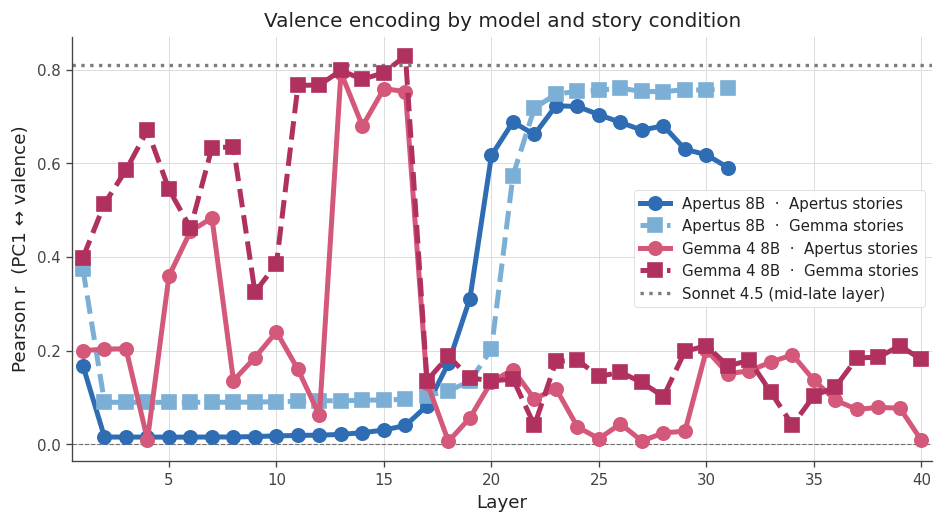

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_arousal_trajectory_combined.png


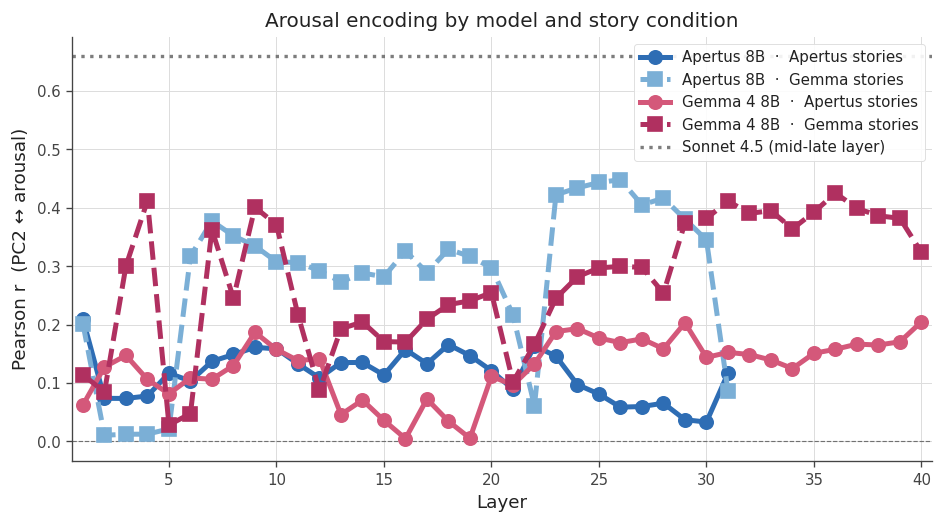

In [9]:
plot_combined_trajectory(
    results, "r_val",
    ylabel="Pearson r  (PC1 ↔ valence)",
    title="Valence encoding by model and story condition",
    x_mode="layer",
    out_path=OUT_DIR / "fig_valence_trajectory_combined.png",
)
plt.show()

plot_combined_trajectory(
    results, "r_aro",
    ylabel="Pearson r  (PC2 ↔ arousal)",
    title="Arousal encoding by model and story condition",
    x_mode="layer",
    out_path=OUT_DIR / "fig_arousal_trajectory_combined.png",
)
plt.show()

## Fractional depth

Same data, x-axis normalised by each model's total layer count. This puts the
two models on a common 0–1 scale and lets you read off "early / mid / late"
behaviour directly. Update `MODEL_TOTAL_LAYERS` above if your checkpoints have
different depths than the defaults (Apertus 8B = 32, Gemma 4 8B = 42).

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_valence_trajectory_combined_fracdepth.png


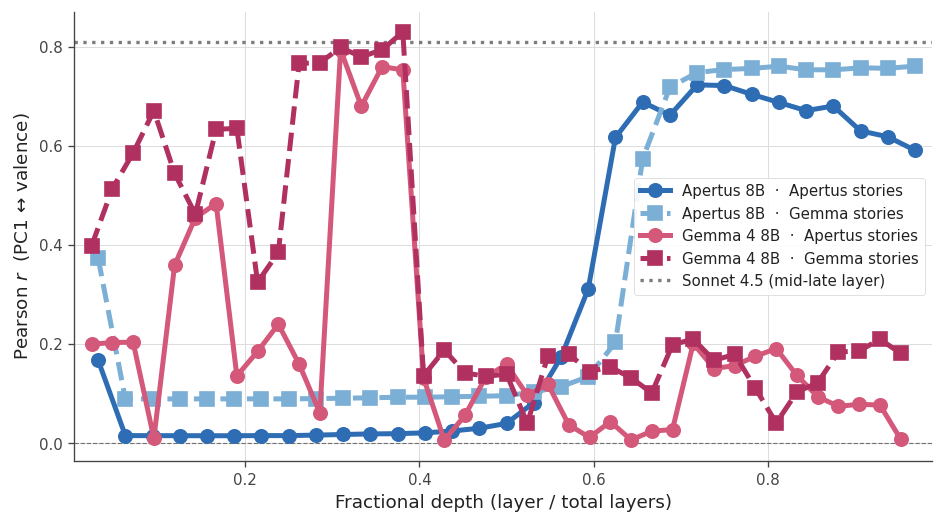

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_arousal_trajectory_combined_fracdepth.png


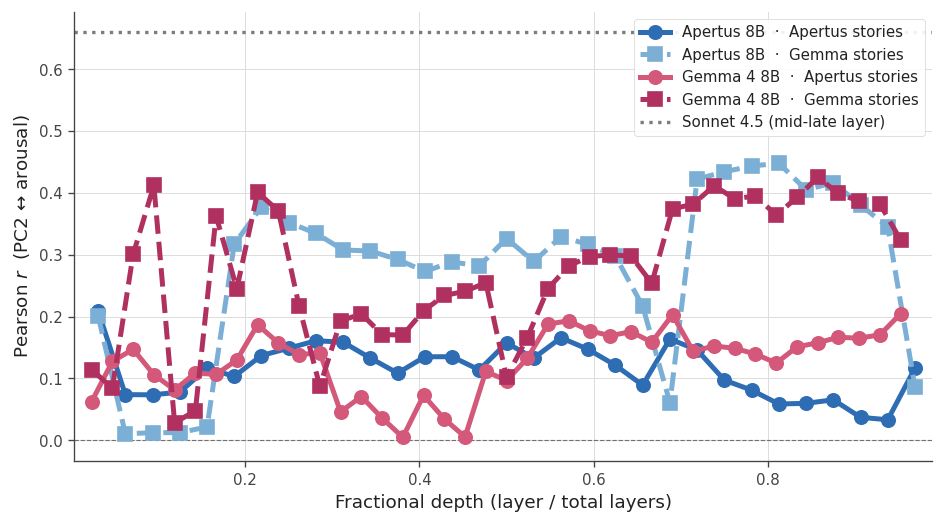

In [10]:
plot_combined_trajectory(
    results, "r_val",
    ylabel=r"Pearson $r$  (PC1 ↔ valence)",
    title=None,
    x_mode="fraction",
    out_path=OUT_DIR / "fig_valence_trajectory_combined_fracdepth.png",
)
plt.show()

plot_combined_trajectory(
    results, "r_aro",
    ylabel=r"Pearson $r$  (PC2 ↔ arousal)",
    title=None,
    x_mode="fraction",
    out_path=OUT_DIR / "fig_arousal_trajectory_combined_fracdepth.png",
)
plt.show()

## Combined valence + arousal panels

Two two-panel layouts that show valence (`r_val`) and arousal (`r_aro`) side
by side on the fractional-depth x-axis:

1. **Horizontal** — `1×2`, valence | arousal, sharing the y-axis.
2. **Vertical**   — `2×1`, valence above arousal, sharing the x-axis.

The legend is drawn once (on the valence panel) since both panels show the
same four (model × story) series.

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_trajectory_combined_fracdepth_horizontal.png


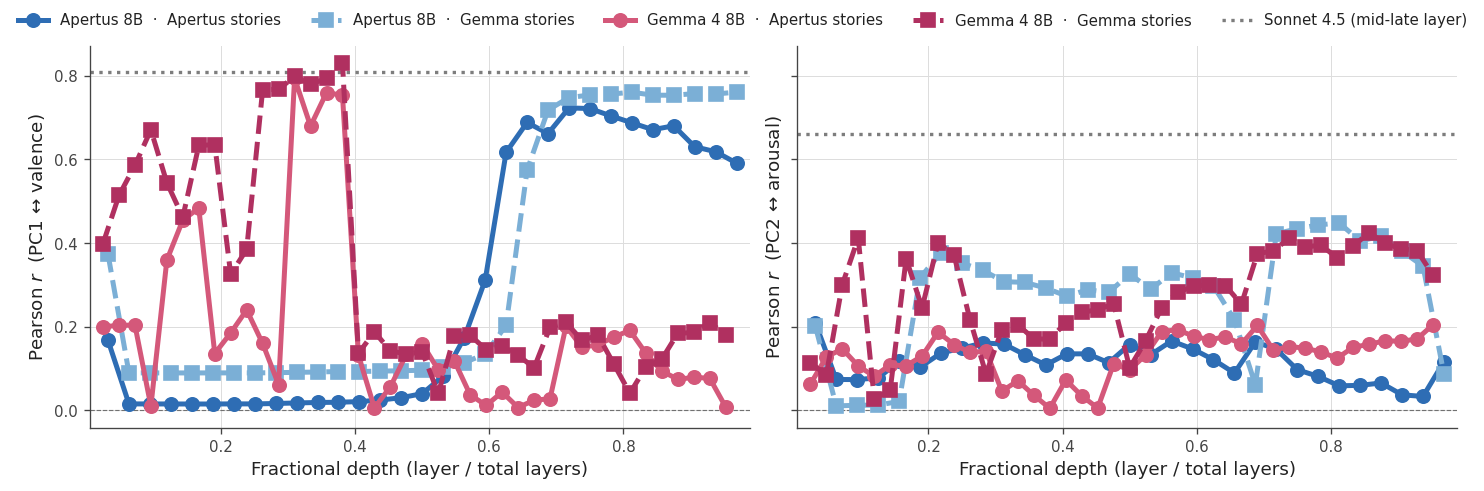

saved → /Users/raphaelbaur/Documents/emotion_experiment/output_compare_models_story_conditions/fig_trajectory_combined_fracdepth_vertical.png


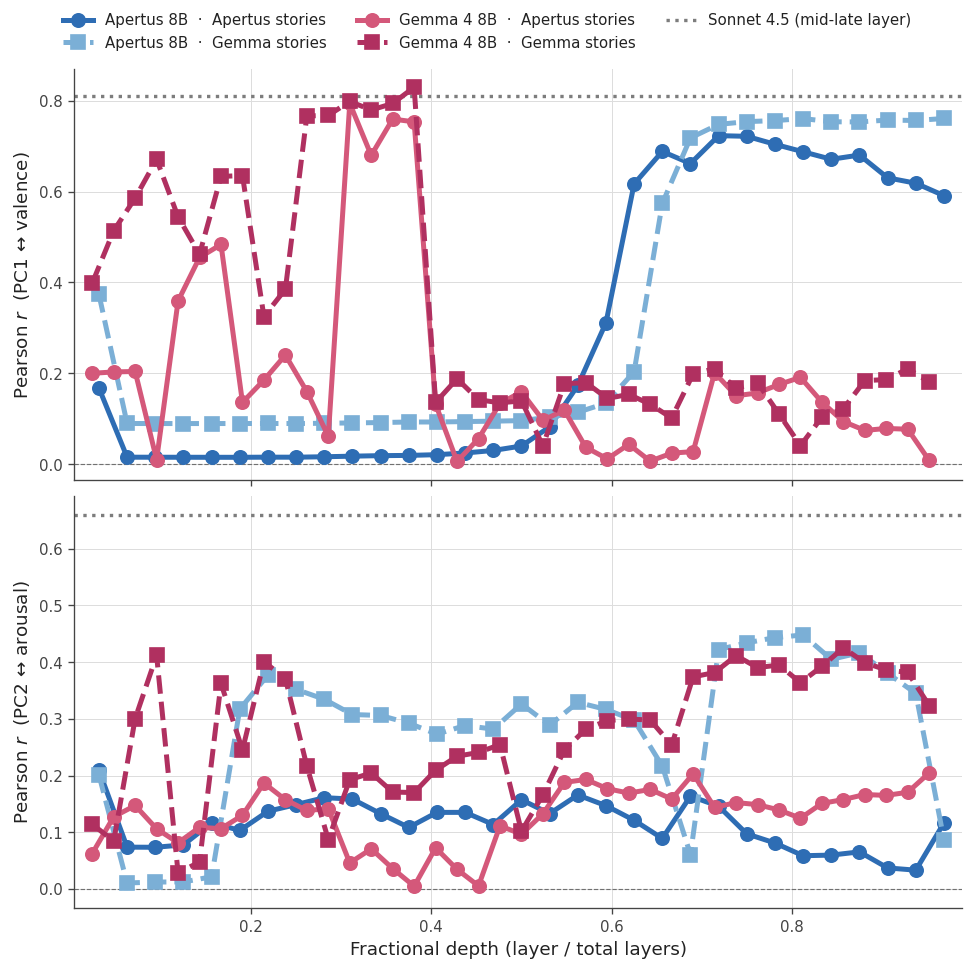

In [11]:
plot_combined_trajectory_both(
    results,
    layout="horizontal",
    x_mode="fraction",
    out_path=OUT_DIR / "fig_trajectory_combined_fracdepth_horizontal.png",
)
plt.show()

plot_combined_trajectory_both(
    results,
    layout="vertical",
    x_mode="fraction",
    out_path=OUT_DIR / "fig_trajectory_combined_fracdepth_vertical.png",
)
plt.show()